# NBA Draft, Players & Performance - Exploration and Cleaning

## Data loading

Load the dataset and display the first 5 rows along with the shape of the DataFrame.

In [19]:
import pandas as pd

df = pd.read_csv('all_seasons.csv')
display(df.head())
print(df.shape)

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


(12844, 22)


## Data exploration

Explore the dataset to understand the distribution of players across draft years, player heights, and draft rounds.
Calculate the average numbers of players per draft year.
Identify years with unusually low participation.
Examine the distribution of player heights and identify any outliers or missing values.

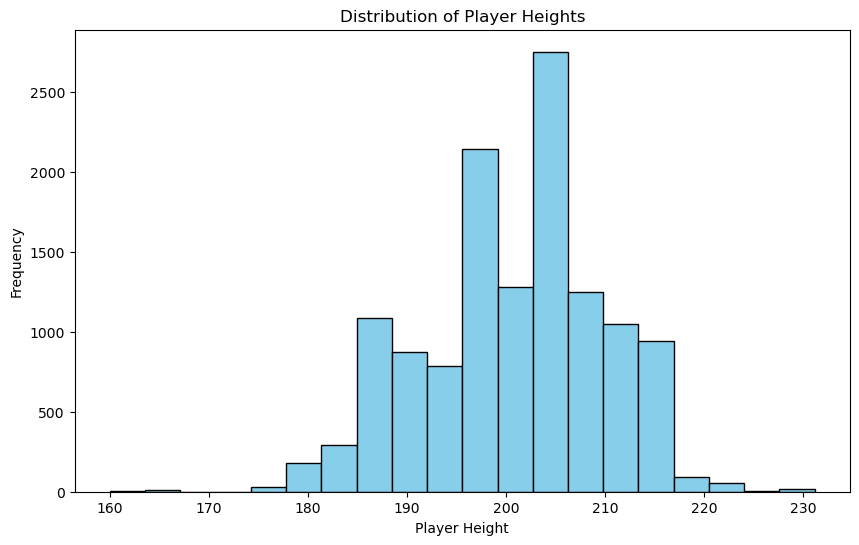

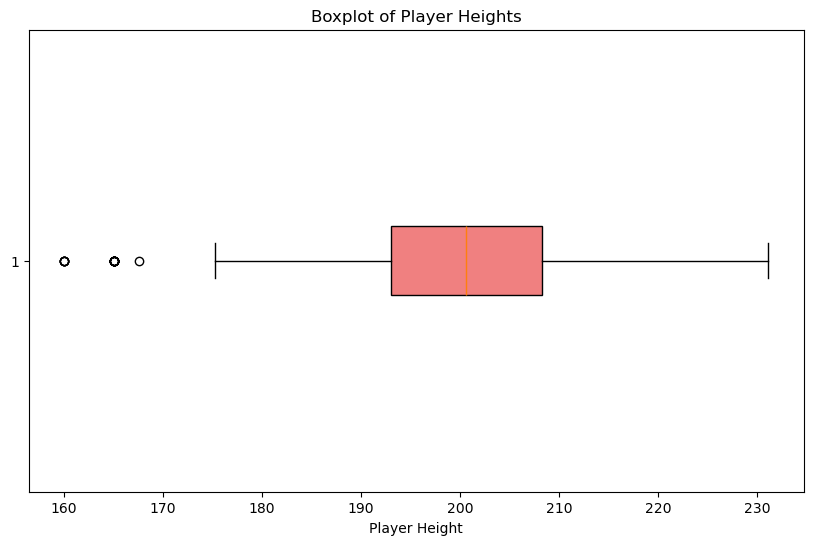

Average players per draft year: 267.5833333333333
Draft years with low player count in dataset:
draft_year
1963      1
1976      1
1978      1
1979      3
1980      3
1981     16
1982     11
1983     22
1984     49
1985     86
1986     52
1987     90
1988    127
1989    123
2021    104
2022     47
Name: count, dtype: int64

Player Height Statistics:
count    12844.000000
mean       200.555097
std          9.111090
min        160.020000
25%        193.040000
50%        200.660000
75%        208.280000
max        231.140000
Name: player_height, dtype: float64

Number of missing height values: 0


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the number of players per draft year
draft_year_counts = df['draft_year'].value_counts().sort_index()

# Calculate the average number of players per draft year
average_players_per_year = draft_year_counts.mean()

# Identify draft years with significantly lower number of players available in the dataset
low_player_years = draft_year_counts[draft_year_counts < average_players_per_year / 2]

# Analyze player height
player_height_stats = df['player_height'].describe()
missing_heights = df['player_height'].isnull().sum()

# Create a histogram of player heights
plt.figure(figsize=(10, 6))
plt.hist(df['player_height'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Player Height')
plt.ylabel('Frequency')
plt.title('Distribution of Player Heights')
plt.show()

# Create a boxplot of player heights
plt.figure(figsize=(10, 6))
plt.boxplot(df['player_height'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
plt.xlabel('Player Height')
plt.title('Boxplot of Player Heights')
plt.show()

# Print key findings
print(f"Average players per draft year: {average_players_per_year}")
print(f"Draft years with low player count in dataset:\n{low_player_years}")
print(f"\nPlayer Height Statistics:\n{player_height_stats}")
print(f"\nNumber of missing height values: {missing_heights}")


## Data cleaning

Clean the data by handling missing values and removing draft years with significantly low # of players in dataset.

In [23]:
# Impute missing values in 'player_height' with the median
median_height = df['player_height'].median()
df_cleaned = df.copy() # Create a copy to avoid modifying the original DataFrame
df_cleaned['player_height'] = df_cleaned['player_height'].fillna(median_height)

# Identify and remove draft years with low participation
years_to_keep = draft_year_counts[draft_year_counts >= average_players_per_year / 2].index
df_cleaned = df_cleaned[df_cleaned['draft_year'].isin(years_to_keep)]

## Finding and Removing Duplicates

Further clean the data by identifying duplicates through column player_name and dropping duplicates. Then save final df to .csv file.

In [33]:
column_name = 'player_name' # Replace 'your_column' with the actual column name
duplicates = df_cleaned[column_name].duplicated()
print(duplicates)

0        False
1        False
2        False
4        False
6        False
         ...  
12837     True
12839     True
12840    False
12841     True
12843     True
Name: player_name, Length: 12108, dtype: bool


In [35]:
num_duplicates = df_cleaned[column_name].duplicated().sum()
print(f"Number of duplicates in '{column_name}': {num_duplicates}")

Number of duplicates in 'player_name': 9808


In [37]:
duplicate_rows = df_cleaned[df[column_name].duplicated(keep=False)]
print(duplicate_rows)

       Unnamed: 0       player_name team_abbreviation   age  player_height  \
0               0  Randy Livingston               HOU  22.0         193.04   
2               2      George Lynch               VAN  26.0         203.20   
4               4      George Zidek               DEN  23.0         213.36   
6               6  Gheorghe Muresan               WAS  26.0         231.14   
8               8    Glenn Robinson               MIL  24.0         200.66   
...           ...               ...               ...   ...            ...   
12836       12836        Joe Harris               BKN  31.0         198.12   
12837       12837        Joe Ingles               MIL  35.0         205.74   
12839       12839       Joel Embiid               PHI  29.0         213.36   
12841       12841      John Collins               ATL  25.0         205.74   
12843       12843    JaMychal Green               GSW  33.0         205.74   

       player_weight          college    country draft_year dra

/var/folders/j3/3sjp9s813kq1hbvxhr8n4t7c0000gn/T/ipykernel_39782/921128937.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicate_rows = df_cleaned[df[column_name].duplicated(keep=False)]


In [46]:
df_no_duplicates = df_cleaned.drop_duplicates(subset=[column_name], keep='first')
print(df_no_duplicates)
df_no_duplicates.to_csv('NBA_cleaned_data.csv', index=False)

       Unnamed: 0         player_name team_abbreviation   age  player_height  \
0               0    Randy Livingston               HOU  22.0         193.04   
1               1    Gaylon Nickerson               WAS  28.0         190.50   
2               2        George Lynch               VAN  26.0         203.20   
4               4        George Zidek               DEN  23.0         213.36   
6               6    Gheorghe Muresan               WAS  26.0         231.14   
...           ...                 ...               ...   ...            ...   
12804       12804         Jordan Hall               SAS  21.0         200.66   
12818       12818       Johnny Juzang               UTA  22.0         198.12   
12826       12826  Jeenathan Williams               POR  24.0         195.58   
12827       12827     Jeff Dowtin Jr.               TOR  26.0         190.50   
12840       12840     John Butler Jr.               POR  20.0         213.36   

       player_weight                col